In [146]:
"""
@author Kevin Nguyen
"""
# Necessary Imports
import pandas
import utilities

df = utilities.combine_data_folder()
df

AttributeError: 'DataFrame' object has no attribute 'concat'

# Predicting the NBA MVP

To start off the project, we need to consider some form of validation before deciding anything else. Because the data is season oriented, we want to use time cross validation instead of the normal k-fold cross validation. This is to prevent data leakage: future seasons should not influence the prediction of past seasons. Since there are a different different number of players in each season, the imported time cross validation will not do. The splits using that library are usually uniform. Here I implemented a time cross validation function that will suffice for the project.

In [143]:
# A function that preforms time cross validation on special NBA data
# Input: Regression 'model' to be tested, 'df' containing the data
# Output: A list of objects: 
def time_cross_validation(model, df=None, features=None):
    
    if features is None:
        features = [feature for feature in df.columns.to_list() if feature not in ['Player', 'Share', 'Year']]
    
    years = list(range(2005, 2025))
    results = []
    right = 0
    wrong = 0

    for year in years:
        train_df = df[df['Year'] < year]
        test_df = df[df['Year'] == year]
        
        X_train = train_df[features]
        y_train = train_df['Share'] 

        X_test = test_df[features]
        y_test = test_df['Share']

        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(np.mean((np.array(y_test) - np.array(y_pred))**2))

        test_copy = test_df.copy()
        test_copy['Predicted Share'] = y_pred
        actual_mvp = test_copy.sort_values('Share', ascending=False).iloc[0]['Player']
        predicted_mvp = test_copy.sort_values('Predicted Share', ascending=False).iloc[0]['Player']
        top_five = test_copy.sort_values('Predicted Share', ascending=False).iloc[0:5]['Player'].to_list()

        results.append({
            "Train Years": [2004, year-1],
            "Test Year": year,
            "RMSE": rmse,
            "Predicted MVP": predicted_mvp,
            "Actual MVP": actual_mvp,
            "Top Five": top_five
        })

        if year == 2024:
            feature_importances = model.feature_importances_

        if predicted_mvp == actual_mvp:
            right += 1
        else:
            wrong += 1

    print("Right: " + str(right) + ", Wrong: " + str(wrong))


    return results, feature_importances


XGBoost will be the model we use. Since we do not have a lot of data, a Neural Network would be overkill. A RandomForest is usuable, but I decided on XGBoost because it works well with tabular data and preforms better in general (from what I've read online)

[0]	validation_0-rmse:0.05636
[10]	validation_0-rmse:0.05167
[20]	validation_0-rmse:0.05246
[30]	validation_0-rmse:0.05427
[0]	validation_0-rmse:0.05303
[10]	validation_0-rmse:0.04744
[20]	validation_0-rmse:0.04371
[30]	validation_0-rmse:0.04121
[40]	validation_0-rmse:0.04005
[50]	validation_0-rmse:0.04004
[60]	validation_0-rmse:0.04015
[63]	validation_0-rmse:0.04004
[0]	validation_0-rmse:0.05809
[10]	validation_0-rmse:0.04679
[20]	validation_0-rmse:0.04089
[30]	validation_0-rmse:0.03673
[40]	validation_0-rmse:0.03408
[50]	validation_0-rmse:0.03247
[60]	validation_0-rmse:0.03163
[70]	validation_0-rmse:0.03107
[80]	validation_0-rmse:0.03065
[90]	validation_0-rmse:0.03055
[100]	validation_0-rmse:0.03042
[110]	validation_0-rmse:0.03027
[120]	validation_0-rmse:0.03025
[130]	validation_0-rmse:0.03020
[140]	validation_0-rmse:0.03017
[150]	validation_0-rmse:0.03014
[160]	validation_0-rmse:0.03013
[170]	validation_0-rmse:0.03009
[180]	validation_0-rmse:0.03009
[190]	validation_0-rmse:0.03007
[

G        0.003794
GS       0.002170
MP       0.002496
FG       0.005548
FGA      0.004659
           ...   
WS/48    0.034297
OBPM     0.003723
DBPM     0.009520
BPM      0.052353
VORP     0.193024
Length: 64, dtype: float32

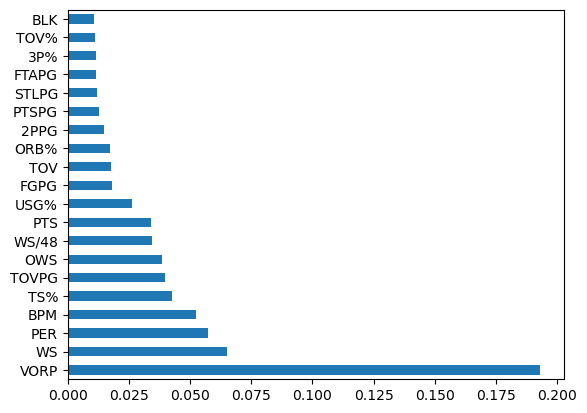

In [144]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,            # More trees for richer patterns
    max_depth=6,                 # Deeper trees for complex relationships
    learning_rate=0.05,          # Lower rate for better convergence
    subsample=0.8,               # Randomly sample rows to reduce overfitting
    colsample_bytree=0.8,        # Randomly sample features
    early_stopping_rounds=20,
    eval_metric='rmse'
)

results, feature_importances = time_cross_validation(model, df)
features = [feature for feature in df.columns.to_list() if feature not in ['Player', 'Share', 'Year']]
feat_importances = pd.Series(feature_importances, index=features)
feat_importances.nlargest(5).plot(kind='barh')
feat_importances